In [ ]:
# Import required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [ ]:
# 1. Load MNIST Dataset
(X_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalize
x_train = x_train/ 255.0
x_test = x_test / 255.0

In [ ]:
# 2. Create Model Function
def create_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),   # 28x28 → 784
        layers.Dense(128, activation='relu'),   # Hidden layer 1
        layers.Dense(64, activation='relu'),    # Hidden layer 2
        layers.Dense(10, activation='softmax')  # Output layer
    ])
    return model


In [ ]:
# CASE 1: Fixed Learning Rate (Adam)
model_fixed = create_model()

model_fixed.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # Fixed LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8581 - loss: 0.4722 - val_accuracy: 0.9616 - val_loss: 0.1369
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9643 - loss: 0.1151 - val_accuracy: 0.9657 - val_loss: 0.1095
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9764 - loss: 0.0746 - val_accuracy: 0.9707 - val_loss: 0.0949
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9819 - loss: 0.0570 - val_accuracy: 0.9718 - val_loss: 0.0911
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9872 - loss: 0.0434 - val_accuracy: 0.9643 - val_loss: 0.1241
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9888 - loss: 0.0347 - val_accuracy: 0.9722 - val_loss: 0.0989
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9910 - loss: 0.0266 - val_accuracy: 0.9759 - val_loss: 0.0942
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9937 - loss: 0.0198 - 

In [ ]:
# CASE 2: Learning Rate Scheduling
def lr_scheduler(epoch, lr):
    if epoch > 5:
        return lr * 0.5   # Reduce LR after 5 epochs
    return lr

lr_callback = keras.callbacks.LearningRateScheduler(lr_scheduler)

model_sched = create_model()

model_sched.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sched = model_sched.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[lr_callback]   # Apply scheduler
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8652 - loss: 0.4756 - val_accuracy: 0.9597 - val_loss: 0.1412 - learning_rate: 0.0010
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9652 - loss: 0.1173 - val_accuracy: 0.9687 - val_loss: 0.1032 - learning_rate: 0.0010
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9756 - loss: 0.0794 - val_accuracy: 0.9684 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9825 - loss: 0.0550 - val_accuracy: 0.9710 - val_loss: 0.0972 - learning_rate: 0.0010
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9872 - loss: 0.0404 - val_accuracy: 0.9721 - val_loss: 0.0921 - learning_rate: 0.0010
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9888 - loss: 0.0337 - val_accuracy: 0.9711 - val_loss: 0.1005 - learning_rate: 0.0010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9939 - l

In [ ]:
# CASE 3: Early Stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',       # Monitor validation loss
    patience=3,               # Stop if no improvement for 3 epochs
    restore_best_weights=True
)

model_early = create_model()

model_early.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_early = model_early.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=[early_stop]   # Apply early stopping
)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8632 - loss: 0.4618 - val_accuracy: 0.9508 - val_loss: 0.1628
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9640 - loss: 0.1200 - val_accuracy: 0.9677 - val_loss: 0.1082
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9755 - loss: 0.0802 - val_accuracy: 0.9732 - val_loss: 0.0892
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9819 - loss: 0.0577 - val_accuracy: 0.9708 - val_loss: 0.0960
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9872 - loss: 0.0405 - val_accuracy: 0.9719 - val_loss: 0.1055
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9879 - loss: 0.0374 - val_accuracy: 0.9748 - val_loss: 0.0952


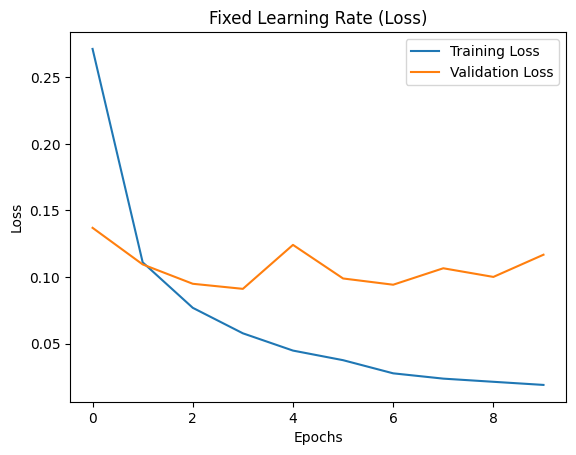

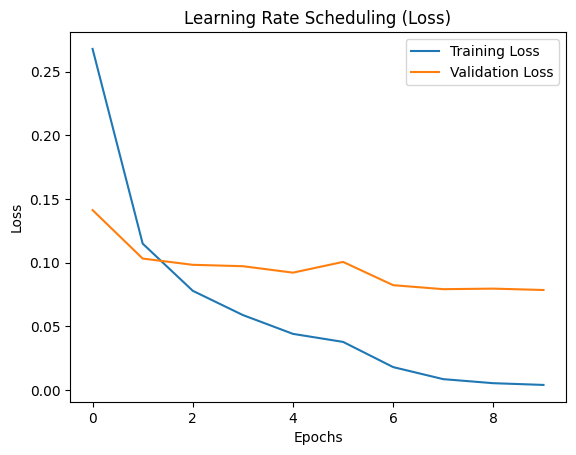

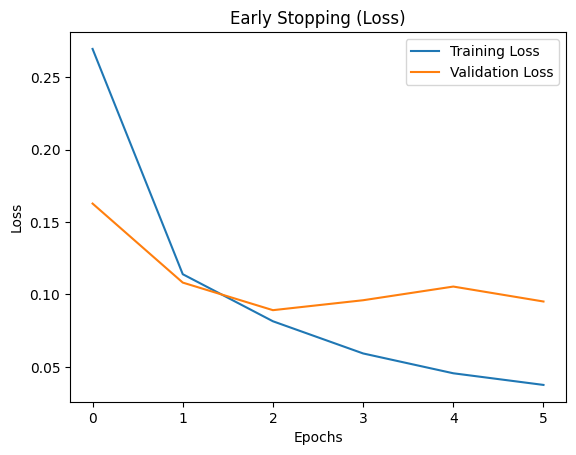

Fixed LR Test Accuracy: 0.972599983215332
LR Scheduling Test Accuracy: 0.9822999835014343
Early Stopping Test Accuracy: 0.975600004196167


In [ ]:
# Plot Validation Loss Comparison
plt.figure()
plt.plot(history_fixed.history['loss'], label='Training Loss')
plt.plot(history_fixed.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Fixed Learning Rate (Loss)")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_sched.history['loss'], label='Training Loss')
plt.plot(history_sched.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Rate Scheduling (Loss)")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_early.history['loss'], label='Training Loss')
plt.plot(history_early.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Early Stopping (Loss)")
plt.legend()
plt.show()


print("Fixed LR Test Accuracy:",
      model_fixed.evaluate(x_test, y_test, verbose=0)[1])

print("LR Scheduling Test Accuracy:",
      model_sched.evaluate(x_test, y_test, verbose=0)[1])

print("Early Stopping Test Accuracy:",
      model_early.evaluate(x_test, y_test, verbose=0)[1])
